<a href="https://colab.research.google.com/github/RMoulla/BDA_Avril26/blob/main/TP_Classification_Spam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification de messages spam avec CountVectorizer

Objectif : entraîner deux modèles de classification sur le fichier `spam.csv` :

- une **régression logistique** ;
- un **random forest**.

La vectorisation du texte est réalisée avec `CountVectorizer`.

## 1. Importation des bibliothèques

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt

## 2. Chargement du fichier

Le fichier `spam.csv` contient généralement plusieurs colonnes, dont seules les deux premières sont utiles :

- `v1` : la classe du message (`ham` ou `spam`) ;
- `v2` : le contenu textuel du message.

On utilise l'encodage `latin-1`, car ce fichier provoque souvent une erreur avec l'encodage UTF-8.

In [2]:
df = pd.read_csv("spam.csv", encoding="latin-1")

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## 3. Exploration rapide du jeu de données

In [3]:
df.shape

(5572, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [5]:
df.isna().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


In [6]:
df["v1"].value_counts()

,count
v1,
ham,4825
spam,747


Visualisation de la distribution des classes.

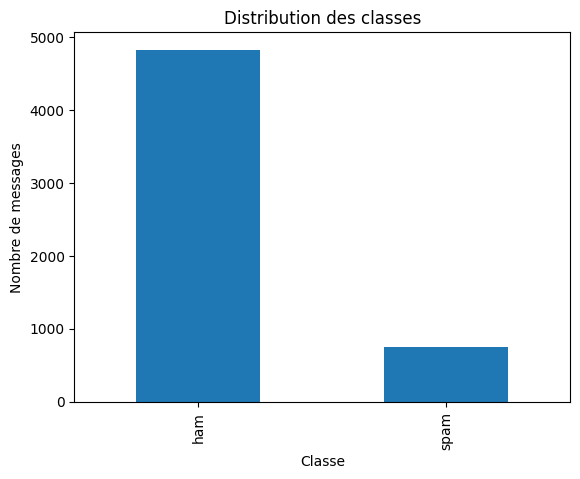

In [7]:
df["v1"].value_counts().plot(kind="bar")
plt.title("Distribution des classes")
plt.xlabel("Classe")
plt.ylabel("Nombre de messages")
plt.show()

## 4. Préparation des données

On conserve uniquement les colonnes utiles, puis on les renomme pour avoir des noms plus explicites.

In [8]:
df = df[["v1", "v2"]]
df.columns = ["label", "message"]

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


On encode la variable cible :

- `ham` devient `0` ;
- `spam` devient `1`.

Ainsi, les métriques de rappel, précision et F1-score seront calculées pour la classe positive `spam`.

In [9]:
df["target"] = df["label"].map({"ham": 0, "spam": 1})

df.head()

,label,message,target
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [10]:
X = df["message"]
y = df["target"]

## 5. Découpage train / test

On utilise un découpage stratifié afin de conserver la même proportion de spams dans le train et dans le test.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Taille du train :", X_train.shape)
print("Taille du test :", X_test.shape)

Taille du train : (4457,)
Taille du test : (1115,)


## 6. Fonction d'évaluation

Cette fonction permet d'évaluer un modèle avec les quatre métriques demandées.

In [12]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred)
    }

    return metrics, y_pred

## 7. Modèle 1 : régression logistique

On construit un pipeline avec :

1. `CountVectorizer`, pour transformer les messages en matrice de comptage des mots ;
2. `LogisticRegression`, pour entraîner un modèle de classification.

In [13]:
logistic_model = Pipeline([
    ("vectorizer", CountVectorizer()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_model.fit(X_train, y_train)

Pipeline(steps=[('vectorizer', CountVectorizer()),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [14]:
logistic_metrics, y_pred_logistic = evaluate_model(logistic_model, X_test, y_test)

logistic_metrics

{'accuracy': 0.9811659192825112,
 'precision': 0.9923076923076923,
 'recall': 0.8657718120805369,
 'f1_score': 0.9247311827956989}

Matrice de confusion pour la régression logistique.

In [15]:
confusion_matrix(y_test, y_pred_logistic)

array([[965,   1],
       [ 20, 129]])

Rapport de classification détaillé.

In [16]:
print(classification_report(y_test, y_pred_logistic, target_names=["ham", "spam"]))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.99      0.87      0.92       149

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.96      1115
weighted avg       0.98      0.98      0.98      1115



## 8. Modèle 2 : random forest

On utilise la même logique :

1. `CountVectorizer` pour représenter les textes ;
2. `RandomForestClassifier` pour la classification.

In [17]:
rf_model = Pipeline([
    ("vectorizer", CountVectorizer()),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('vectorizer', CountVectorizer()),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [18]:
rf_metrics, y_pred_rf = evaluate_model(rf_model, X_test, y_test)

rf_metrics

{'accuracy': 0.9739910313901345,
 'precision': 1.0,
 'recall': 0.8053691275167785,
 'f1_score': 0.8921933085501859}

Matrice de confusion pour le random forest.

In [19]:
confusion_matrix(y_test, y_pred_rf)

array([[966,   0],
       [ 29, 120]])

Rapport de classification détaillé.

In [20]:
print(classification_report(y_test, y_pred_rf, target_names=["ham", "spam"]))

              precision    recall  f1-score   support

         ham       0.97      1.00      0.99       966
        spam       1.00      0.81      0.89       149

    accuracy                           0.97      1115
   macro avg       0.99      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



## 9. Comparaison des modèles

In [21]:
results = pd.DataFrame([
    {"model": "Régression logistique", **logistic_metrics},
    {"model": "Random forest", **rf_metrics}
])

results

,model,accuracy,precision,recall,f1_score
0,Régression logistique,0.981166,0.992308,0.865772,0.924731
1,Random forest,0.973991,1.000000,0.805369,0.892193


## 10. Tester le modèle sur de nouveaux messages

On peut maintenant utiliser le meilleur modèle pour prédire si un nouveau message est un spam ou non.

In [23]:
new_messages = [
    "Congratulations! You have won a free ticket. Call now!",
    "Hi, are we still meeting tomorrow?"
]

predictions = logistic_model.predict(new_messages)

for message, prediction in zip(new_messages, predictions):
    label = "spam" if prediction == 1 else "ham"
    print(f"{message} --> {label}")

Congratulations! You have won a free ticket. Call now! --> spam
Hi, are we still meeting tomorrow? --> ham


## 11. Conclusion

Ce notebook a permis de :

- charger et préparer un jeu de données textuel ;
- vectoriser les messages avec `CountVectorizer` ;
- entraîner une régression logistique ;
- entraîner un random forest ;
- comparer les deux modèles avec l'accuracy, le rappel, la précision et le F1-score.

Dans ce type de problème, le rappel est particulièrement important si l'objectif est de détecter un maximum de spams. La précision est importante si l'on veut éviter de classer trop de messages légitimes comme des spams.